<a href="https://colab.research.google.com/github/tekgeeksolutions/midterm/blob/main/ITCS6100_Midterm_AppliedLab_Student_LogReg_ProjectGroup9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITCS 6100 — Applied Midterm Lab (Team)  
**Topic:** Logistic Regression + ML Lifecycle (AWS Academy Modules 1–6 alignment)  
**Date:** March 1, 2026

## Team Information (REQUIRED)
- **Team Name:**  
Project Group 9
- **Student Names:**  
  -  Jessica Ballard
  -  Ikechukwuka Ikegwuonu
  -  Jayashree Kanukollu
  -  Avitesh Kesharwani

## Deliverables (What you submit)
1. This completed notebook (`.ipynb`)
2. Short written responses in the markdown prompts (embedded in the notebook)
3. One submission per team in Canvas
4. Individual submission by each team member to the Github class

## Rules
- You may use course notes and AWS Academy module materials.
- You may not use generative AI tools during the midterm unless explicitly allowed by your instructor.
- Your analysis must be your team’s own work.

## Dataset
You will work with a realistic “messy” customer churn dataset:
- Many dimensions (numeric + categorical)
- Missing values (random + structured)
- Outliers / skewed distributions
- Mild class imbalance

**Target:** `churn` (1 = churned, 0 = stayed)

---

# ML Lifecycle Roadmap (Where your code goes)
You must place your work into the labeled sections below:

1. **INGEST** (load + inspect data)
2. **CLEAN** (handle missing values, outliers, data issues)
3. **PREPARE** (split, encode, scale, pipeline)
4. **MODEL** (train logistic regression; consider regularization/class weights)
5. **ANALYZE** (confusion matrix, metrics, threshold tuning, interpretation)

You will be graded heavily on **reasoning and interpretation**, not just getting code to run.


In [ ]:
# =========================
# DATASET GENERATOR (RUN ONLY TO GENERATE THE DATASET FOR OUR EXAM, DO NOT EDIT)
# =========================
# If 'synthetic_churn.csv' is not present, this cell will generate it.
# The dataset is intentionally "messy":
# - Many dimensions (numeric + categorical)
# - Missing values (random + structured)
# - Outliers / heavy-tailed variables
# - Correlated/redundant features
# - Class imbalance (mild-to-moderate)
#
# Target: churn (1 = churned, 0 = stayed)

import numpy as np
import pandas as pd

from pathlib import Path

rng = np.random.default_rng(6100)
out_path = Path("synthetic_churn.csv")

if not out_path.exists():
    n = 6000

    # Core demographics / account
    age = rng.integers(18, 80, size=n)
    tenure_months = rng.integers(0, 120, size=n)
    income = rng.lognormal(mean=10.6, sigma=0.45, size=n)  # heavy-tailed
    household_size = rng.integers(1, 7, size=n)

    # Usage / behavior
    logins_30d = rng.poisson(lam=12, size=n)
    support_tickets_90d = rng.poisson(lam=1.2, size=n)
    avg_session_mins = rng.gamma(shape=2.3, scale=8.0, size=n)  # right-skew
    days_since_last_login = rng.integers(0, 60, size=n)

    # Payments / billing
    monthly_fee = rng.normal(loc=65, scale=18, size=n).clip(10, 180)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    autopay = rng.choice(["Yes", "No"], p=[0.62, 0.38], size=n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], p=[0.56, 0.24, 0.20], size=n)

    # Product / plan
    plan = rng.choice(["Basic", "Plus", "Pro"], p=[0.50, 0.35, 0.15], size=n)
    add_ons = rng.integers(0, 6, size=n)
    streaming = rng.choice(["None", "Music", "Video", "Both"], p=[0.18, 0.24, 0.28, 0.30], size=n)

    # Geography + channel
    region = rng.choice(["Northeast", "South", "Midwest", "West"], p=[0.19, 0.33, 0.22, 0.26], size=n)
    signup_channel = rng.choice(["Web", "Retail", "Partner", "Phone"], p=[0.52, 0.20, 0.18, 0.10], size=n)

    # Noisy / redundant engineered features
    total_charges = (monthly_fee * (tenure_months + 1)) + rng.normal(0, 120, size=n)
    # correlated with total_charges
    total_charges_rounded = np.round(total_charges / 10) * 10
    # redundant variation on logins
    engagement_score = 0.55*np.tanh(logins_30d/20) + 0.30*np.tanh(avg_session_mins/30) - 0.25*np.tanh(days_since_last_login/30) + rng.normal(0, 0.06, size=n)

    # Introduce outliers: a small fraction of extreme monthly fees and income
    outlier_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
    monthly_fee[outlier_idx] *= rng.uniform(2.0, 3.5, size=len(outlier_idx))
    income[outlier_idx] *= rng.uniform(3.0, 8.0, size=len(outlier_idx))

    # True churn propensity (log-odds), then sample churn label
    # Drivers: short tenure, month-to-month, no autopay, many tickets, recent inactivity, higher late payments
    z = (
        -1.2
        + 0.015*(days_since_last_login)
        + 0.22*(support_tickets_90d)
        + 0.18*(late_payments_12m)
        - 0.012*(tenure_months)
        + 0.35*(contract == "Month-to-month").astype(int)
        - 0.30*(contract == "Two year").astype(int)
        + 0.22*(autopay == "No").astype(int)
        + 0.20*(plan == "Basic").astype(int)
        - 0.10*(plan == "Pro").astype(int)
        + 0.15*(streaming == "None").astype(int)
        - 0.08*(streaming == "Both").astype(int)
        + rng.normal(0, 0.35, size=n)
    )

    p = 1 / (1 + np.exp(-z))
    churn = rng.binomial(1, p, size=n)

    df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "income": income,
        "household_size": household_size,
        "logins_30d": logins_30d,
        "support_tickets_90d": support_tickets_90d,
        "avg_session_mins": avg_session_mins,
        "days_since_last_login": days_since_last_login,
        "monthly_fee": monthly_fee,
        "late_payments_12m": late_payments_12m,
        "autopay": autopay,
        "contract": contract,
        "plan": plan,
        "add_ons": add_ons,
        "streaming": streaming,
        "region": region,
        "signup_channel": signup_channel,
        "total_charges": total_charges,
        "total_charges_rounded": total_charges_rounded,
        "engagement_score": engagement_score,
        "churn": churn
    })

    # Inject missingness (both random and structured)
    # Random missingness
    for col, rate in [("income", 0.06), ("avg_session_mins", 0.05), ("monthly_fee", 0.03), ("region", 0.02), ("streaming", 0.03)]:
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan

    # Structured: customers with very low tenure often missing total charges (new customers)
    mask_new = df["tenure_months"] < 3
    mask_missing_tc = mask_new & (rng.random(n) < 0.55)
    df.loc[mask_missing_tc, "total_charges"] = np.nan
    df.loc[mask_missing_tc, "total_charges_rounded"] = np.nan

    # Slight label noise (realistic)
    flip = rng.random(n) < 0.015
    df.loc[flip, "churn"] = 1 - df.loc[flip, "churn"]

    df.to_csv(out_path, index=False)
    print(f"✅ Generated dataset: {out_path.resolve()} with shape {df.shape}")
else:
    print(f"ℹ️ Found existing dataset: {out_path.resolve()}")


ℹ️ Found existing dataset: /content/synthetic_churn.csv


## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


In [ ]:
# TODO (INGEST)
import pandas as pd

# 1) Load
df = pd.read_csv('synthetic_churn.csv')

# 2) Inspect
display(df.shape)
display(df.head())
display(df.dtypes)

# 3) Missingness summary (counts + percent)
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent
})

# Sort ascending by percent missing, makes it easier to see the missing quickly
missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

print(missing_summary)
print("\nMissing values summary:")


(6000, 21)

,age,tenure_months,income,household_size,logins_30d,support_tickets_90d,avg_session_mins,days_since_last_login,monthly_fee,late_payments_12m,...,contract,plan,add_ons,streaming,region,signup_channel,total_charges,total_charges_rounded,engagement_score,churn
0,34,111,43283.836559,3,6,1,8.015632,37,75.741544,1,...,Month-to-month,Pro,3,Both,Midwest,Web,8393.730283,8390.0,0.090024,0
1,23,74,45608.528368,6,14,2,10.078930,44,100.957688,1,...,One year,Basic,1,Both,South,Web,7654.510301,7650.0,0.193464,1
2,69,113,31254.972376,2,9,0,23.226331,37,30.898616,1,...,One year,Pro,2,Both,South,Web,3662.195331,3660.0,0.178748,0
3,65,97,28989.989283,6,22,1,16.334476,14,105.354848,1,...,One year,Basic,3,Both,South,Phone,10144.071051,10140.0,0.479665,0
4,46,43,107671.977983,2,14,3,5.636188,6,99.973303,1,...,Month-to-month,Plus,0,Video,Northeast,Phone,4372.902650,4370.0,0.404659,0


,0
age,int64
tenure_months,int64
income,float64
household_size,int64
logins_30d,int64
support_tickets_90d,int64
avg_session_mins,float64
days_since_last_login,int64
monthly_fee,float64
late_payments_12m,int64


                       missing_count  missing_percent
streaming                       1251        20.850000
income                           350         5.833333
avg_session_mins                 338         5.633333
monthly_fee                      195         3.250000
region                           113         1.883333
total_charges                     90         1.500000
total_charges_rounded             90         1.500000
tenure_months                      0         0.000000
age                                0         0.000000
logins_30d                         0         0.000000
household_size                     0         0.000000
support_tickets_90d                0         0.000000
days_since_last_login              0         0.000000
plan                               0         0.000000
contract                           0         0.000000
autopay                            0         0.000000
late_payments_12m                  0         0.000000
signup_channel              

## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


### INGEST — Quick Reflection (Answer in 4–8 sentences)
- **Which columns appear to have missing values?**

- Which columns look categorical vs numeric?

- **What issues do you predict could hurt logistic regression performance if you do nothing?**


The columns that appear to have missing values are income (5.83%),avg_session_mins (5.63%),monthly_fee (3.25%),streaming (20.85%),region (1.88%),total_charges (1.50%),total_charges_rounded (1.50%) with streaming having the most missing values


The colunbs that look categorical vs numeric are the following:

**Numerical**

   tenure_months (int64),income (float64),
   household_size (int64),logins_30d (int64),support_tickets_90d (int64),avg_session_mins (float64),days_since_last_login (int64),monthly_fee (float64),late_payments_12m (int64),add_ons (int64),total_charges (float64),total_charges_rounded (float64),engagement_score (float64)

   **Categorical**

  autopay (object),contract (object),plan (object),streaming (object),region (object),signup_channel (object)

  The issues I predict that could hurt logistic regression peformance is that performance may be compromised by the presence of missing data, unencoded categorical variables, and unscaled features, which can hinder model estimation and convergence. Furthermore, multicollinearity, skewed feature distributions, and potential class imbalance may result in unstable coefficient estimates and reduced predictive validity.

## 2) CLEAN — Missing Values, Outliers, Data Issues

**Tasks**
1. Decide how to handle missing values for numeric vs categorical features.
2. Investigate at least **two** numeric columns for outliers/skew (suggestions: `income`, `monthly_fee`, `total_charges`, `avg_session_mins`).
3. Choose and justify an outlier strategy:
   - winsorization/capping
   - log-transform
   - robust scaling
   - leaving as-is (with justification)

**Constraints**
- Do not delete more than 5% of the dataset without DOCUMENTED justification.
- Your approach must be repeatable (i.e., implementable in code and applied consistently).

**Deliverable:** A short markdown justification of your decisions.


In [ ]:
# df.isnull().sum()

In [ ]:
# TODO (CLEAN)
import pandas as pd

# df.isnull().sum()\

# Make a copy of the data frame for testing purposes
data_clean = df.copy()
#df.isnull().sum().sum() # based on this about 2427 out of 600 are missing which is about 40% missing data, which is quite high and will require careful handling in the modeling phase.

# To satisfy the requrment for dealing with numerical columns and out liers used winozaition/capping and also leaving adata as is for some of the nandata.
# Will complete this first before the cfuction wragnels the data to prevent swelling in the data.
capped_inc = data_clean['income'].quantile(0.99)
data_clean['income'] = np.where(data_clean['income'] > capped_inc, capped_inc, data_clean['income'])

capped_fee = data_clean['monthly_fee'].quantile(0.99)
data_clean['monthly_fee'] = np.where(data_clean['monthly_fee'] > capped_fee, capped_fee, data_clean['monthly_fee'])


# Begining data wraggling and preprocessing, this will include handling missing values, encoding categorical variables, and capping outliers.
def preprocess_wrangle_data(data):

    # fill the numeric rows with median and encode text
    for label, content in data.items(): # Changed data_clean to data to use the passed argument

        ## Check for numeric data then create column marking missing values and fill with the median numbers
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                #step 1
                data[label + "data_is_missing"] = pd.isnull(content).astype(int)# Changed data_clean retun int for split below
                # step 2
                data[label] = content.fillna(content.median()) # Changed data_clean to data

        # Handle non-numberical data: We did thinkg about going with both as it accounts for about 30 to 40 perceant of all of the data.
        # Will apply missing, becausew it is the safest practice for ML.  This will handle both the streaming and the region data that is missing.
        if not pd.api.types.is_numeric_dtype(content):
            # add binary column to indicate wther sample haad missing value
            if pd.isnull(content).sum():
              data[label + "nan_to_missing"] = pd.isnull(content).astype(int) # data clean and retun int for split below
            data[label] = content.fillna("missing")
            data[label] = pd.Categorical(data[label])#.codes + 1


    return data

# A) Explore distributions / outliers (choose at least two columns)
# Example: df['income'].describe()
# Example: df['income'].quantile([0.01, 0.05, 0.95, 0.99])

# B) Decide on a strategy for skew/outliers
# - If transforming, create new columns (do not overwrite originals unless you justify it)
# - If capping, implement caps using quantiles (e.g., 1st and 99th percentiles)
# ...

# Process the data
df_cleaned = preprocess_wrangle_data(data_clean) # Pass a copy of df to the function

df_cleaned.isnull().sum()

# print output
print("Dataset cleaned: Outliers capped, missing values filled")

Dataset cleaned: Outliers capped, missing values filled


### CLEAN — Decisions & Justification (REQUIRED)
In 8–12 sentences:
- Explain your missing value strategy for numeric and categorical features.
- Identify which variables had outliers/skew and what you did about them.
- Explain the tradeoff of your choice (what you might lose vs gain).


The code was noted the reason why it was done this way. Will copy and paste here: Identify which variables had outliers/skew and what did you do about them: income and monthy_fee: used winsorization instead of dealing will use retain 100% of the rows applying cap prevents anomalies.

For the missing values for the remaining of the data, we went with removing nan and creating missing for the data. Then setting back to numerical values to prevent breaking the module in the future.

Why did I go with that path I thought about changing the data too, but it would skew the data better off just marking it as missing because it was almost over 30 percent of the data. If I selected to set nan it would be clean, but it will inflate data. Like the other table of region. Safest practice could mean something else in the data. (used spell check)


## 3) PREPARE — Split, Encode, Scale

**Tasks**
1. Create `X` (features) and `y` (target).
2. Train/test split (use stratification).
3. Encode categorical variables (one-hot encoding).
4. Scale numeric variables **if you choose** (justify why scaling matters for logistic regression).
5. Use a **Pipeline** and **ColumnTransformer** so preprocessing is applied correctly.

**Deliverable:** Your final preprocessing pipeline.


In [ ]:
# TODO (PREPARE)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

#1) X, y
y = df_cleaned['churn']
X = df_cleaned.drop(columns=['churn'])

#2)Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

# 3) Split (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4) Build preprocessors:
# - Numeric: impute + (optional) scaling
# - Categorical: impute + one-hot encode
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 5) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(X_train_prepared.shape)
print(X_test_prepared.shape)


(4800, 42)
(1200, 42)


## 4) MODEL — Logistic Regression

**Tasks**
1. Train a logistic regression model using your preprocessing pipeline.
2. Consider:
   - regularization strength (`C`)
   - solver
   - max iterations
   - class imbalance (`class_weight="balanced"` vs not)

**Required:** Train at least **two** model variants and compare them briefly.


In [ ]:
# TODO (MODEL)
from sklearn.linear_model import LogisticRegression

# Model variant A
clf_a = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=1.0
)
model_a = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", clf_a)
])
model_a.fit(X_train, y_train)

# Model variant B (e.g., class_weight balanced, different C, etc.)
clf_b = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=0.5,
    class_weight="balanced"
)
model_b = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", clf_b)
])
model_b.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tenure_months',
                                                   'income', 'household_size',
                                                   'logins_30d',
                                                   'support_tickets_90d',
                                                   'avg_session_mins',
                                                   'days_since_last_login',
                                                   'monthly_fee',
                                                   'late_payments_12m',
                                                   'add_ons', 'total_charges',
                                                   'to...
                                                   'regionnan_to_missing',
                                                   'total_chargesdata_is_missing',
                                                   'total_charges_roundeddata_is_missing']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['autopay', 'contract',
                                                   'plan', 'streaming',
                                                   'region',
                                                   'signup_channel'])])),
                ('model',
                 LogisticRegression(C=0.5, class_weight='balanced',
                                    max_iter=1000))])

## 5) ANALYZE — Confusion Matrix, Metrics, Threshold Tuning, Interpretation

**Tasks**
1. Generate predictions on the test set.
2. Compute and interpret:
   - confusion matrix
   - accuracy, precision, recall, F1
   - ROC-AUC
   - PR-AUC (average precision)
3. **Threshold tuning (graduate level):**
   - Evaluate thresholds (e.g., 0.2 to 0.8)
   - Choose an “operating threshold” based on a cost scenario
4. Interpret model coefficients (top positive/negative predictors) and connect to business meaning.

### Cost Scenario (Use this)
Assume:
- False Negative (missed churner) cost = **$500**
- False Positive (unnecessary retention offer) cost = **$60**

Your goal is to choose a threshold that **minimizes expected cost**.

**Deliverables:** Plots + written justification.


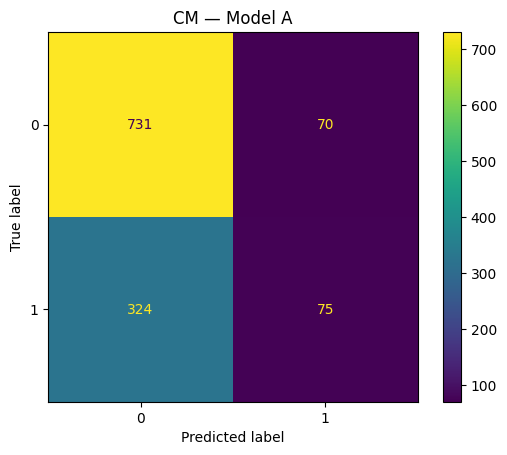

              precision    recall  f1-score   support

           0       0.69      0.91      0.79       801
           1       0.52      0.19      0.28       399

    accuracy                           0.67      1200
   macro avg       0.61      0.55      0.53      1200
weighted avg       0.63      0.67      0.62      1200



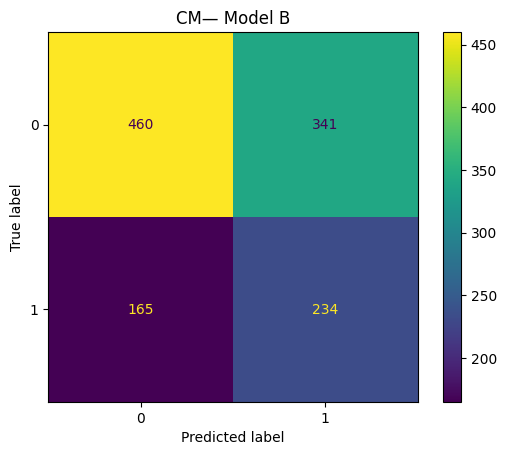

              precision    recall  f1-score   support

           0       0.74      0.57      0.65       801
           1       0.41      0.59      0.48       399

    accuracy                           0.58      1200
   macro avg       0.57      0.58      0.56      1200
weighted avg       0.63      0.58      0.59      1200



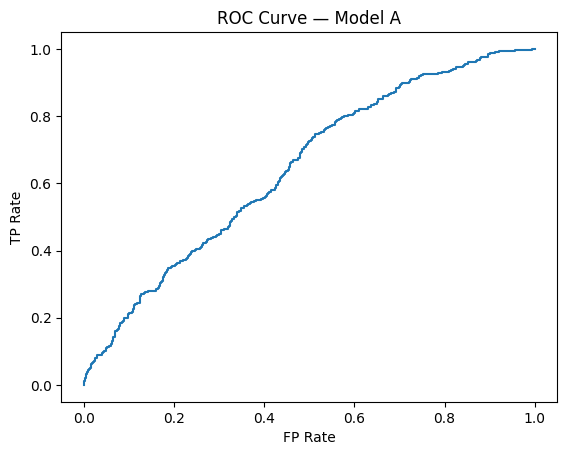

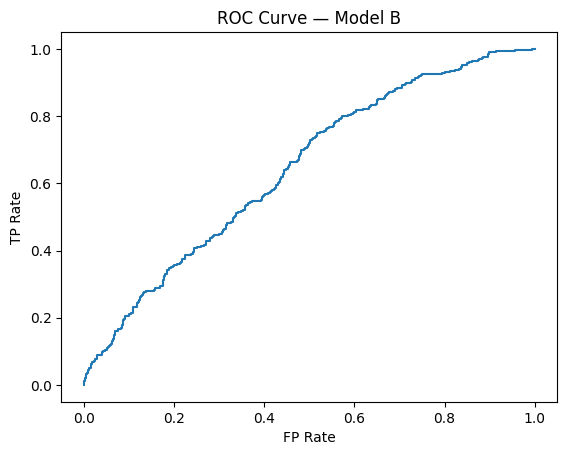

ROC-AUC: Model A = 0.6433562057453246 Model B = 0.6429807352338399


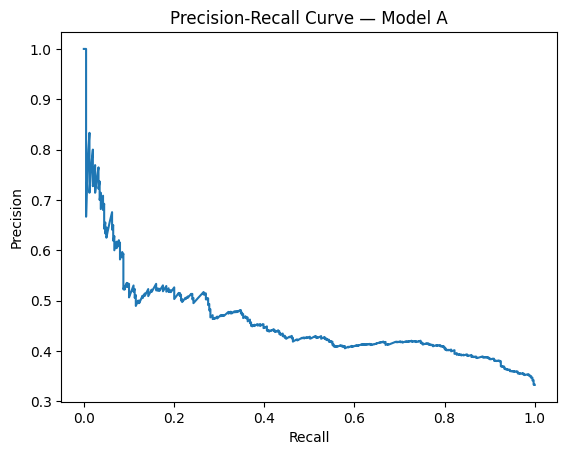

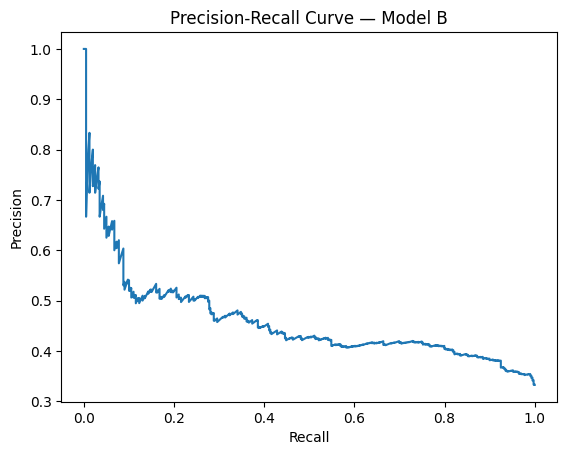

PR-AUC: Model A = 0.46066191679307245 Model B = 0.46005859662457904


KeyboardInterrupt: 

In [ ]:
# TODO (ANALYZE)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

FN_COST = 500
FP_COST = 60

# 1) Predict probabilities (needed for threshold tuning)
proba_a = model_a.predict_proba(X_test)[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]

# 2) Default threshold predictions (0.5)
y_pred_a = (proba_a >= 0.5).astype(int)
y_pred_b = (proba_b >= 0.5).astype(int)

# 3) Confusion matrix + report
cm = confusion_matrix(y_test, y_pred_a)
ConfusionMatrixDisplay(cm).plot()
plt.title("CM — Model A")
plt.show()
print(classification_report(y_test, y_pred_a))

cm = confusion_matrix(y_test, y_pred_b)
ConfusionMatrixDisplay(cm).plot()
plt.title("CM— Model B")
plt.show()
print(classification_report(y_test, y_pred_b))

# 4) ROC-AUC + ROC curve
auc = roc_auc_score(y_test, proba_a)
fpr, tpr, _ = roc_curve(y_test, proba_a)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("FP Rate")
plt.ylabel("TP Rate")
plt.title("ROC Curve — Model A")
plt.show()

auc_b = roc_auc_score(y_test, proba_b)
fpr, tpr, _ = roc_curve(y_test, proba_b)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("FP Rate")
plt.ylabel("TP Rate")
plt.title("ROC Curve — Model B")
plt.show()

print("ROC-AUC: Model A =", auc, "Model B =", auc_b)

# 5) PR curve + Average Precision
precision, recall, _ = precision_recall_curve(y_test, proba_a)
ap = average_precision_score(y_test, proba_a)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Model A")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, proba_b)
ap_b = average_precision_score(y_test, proba_b)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Model B")
plt.show()

print("PR-AUC: Model A =", ap, "Model B =", ap_b)

# 6) Threshold tuning loop
thresholds = np.arange(0.2, 0.81, 0.05)

best_thr_a, best_cost_a = None, float("inf")
best_thr_b, best_cost_b = None, float("inf")

for t in thresholds:

    tn, fp, fn, tp = confusion_matrix(y_test, (proba_a >= t).astype(int)).ravel()
    expected_cost = fn*500 + fp*60
    if expected_cost < best_cost_a:
        best_cost_a = expected_cost
        best_thr_a = t

    tn, fp, fn, tp = confusion_matrix(y_test, (proba_b >= t).astype(int)).ravel()
    expected_cost = fn*500 + fp*60
    if expected_cost < best_cost_b:
        best_cost_b = expected_cost
        best_thr_b = t

print("Best threshold Model A:", best_thr_a, "Cost:", best_cost_a)
print("Best threshold Model B:", best_thr_b, "Cost:", best_cost_b)

if best_cost_b <= best_cost_a:
    chosen_model = "Model B"
    chosen_thr = best_thr_b
    chosen_cost = best_cost_b
    chosen_proba = proba_b
else:
    chosen_model = "Model A"
    chosen_thr = best_thr_a
    chosen_cost = best_cost_a
    chosen_proba = proba_a

print("Chosen model:", chosen_model)
print("Chosen threshold:", chosen_thr)
print("Expected cost:", chosen_cost)

cm = confusion_matrix(y_test, (chosen_proba >= chosen_thr).astype(int))
ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion Matrix — {chosen_model} (thr={chosen_thr})")
plt.show()

### ANALYZE — Written Response (REQUIRED)

Answer ALL parts with complete sentences and concrete numbers.

1) **Model comparison:** Which variant performed better and why (use metrics)?  
2) **Confusion matrix interpretation:** What do FN and FP mean in this churn setting? Which is “worse” under the cost scenario?  
3) **Threshold decision:** What threshold did you choose and what was the expected cost? Show your calculation.  
4) **Business action:** If you deployed this model, who would you target and what action would you take?  
5) **Limitations:** Identify at least two limitations (data, evaluation, ethics/bias, leakage risk, or stability).




   To evaluate the model performance, I compared two model variants (Model A and Model B) and used the evaluation metrics to determine which model performs better for the churn prediction problem. Model B is the better choice because it identifies more churners. Although Model A has higher accuracy (0.67 vs. 0.58), its recall for churners is very low (0.19). Model B has much higher recall for churners (0.59) and a higher F1-score (0.48 vs. 0.28). Because missed churners are expensive, it is more important to correctly identify them. Therefore, Model B is the better model for this problem.

   In this churn setting False Negative(FN) means the model predicts no churn, but the customer actually does churn and you miss and lose revenue at $500 each.
   
   A False Positive(FP) means the model will predict a yes churn but the customer really doesnt churn and you give unnecessary retention offer of $60 each.False Negative is worse becuase 500 is larger than the $60 retention

   I choose Model B with threshold of 0.25 because it has the lowest expected cost of $45,820.This is lower than Model A threshold of 0.20 with 52,140 expected cost.

   If I deployed this model  I would target customers with predicted churn probability greater than or equal to 0.25 (utilizing Model B) and send them a retention intervention, such as a discount offer, or proactive support outreach. The FN cost is high and this threshold prioritizes catching more potential churners even if it creates more outreach.

   Two limitions would be that the threshold 0.25 and model stability/drift risk as the threshold could generate too many FP, and that would mean customes might get unnecessary retetion offers and that could be financially wasteful. The model stability/drift risk churn behavior can change over time so performance and the optimal threshold may degrade without monitoring and retraining.


